In [28]:
# ===========================================
# 📦 Import Libraries
# ===========================================
import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords if not already
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

print("✅ Libraries loaded successfully.")


✅ Libraries loaded successfully.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [29]:
# ===========================================
# 🧩 Load Model and Vectorizer
# ===========================================
clf = joblib.load("software_roles_model.pkl")
vectorizer = joblib.load("vectorizer.pkl")

print("✅ Model and vectorizer loaded successfully.")


✅ Model and vectorizer loaded successfully.


In [30]:
# ===========================================
# 📂 Load Dataset
# ===========================================
df = pd.read_csv("./data/Resume/Resume_extended.csv")
print(f"Dataset loaded: {df.shape[0]} samples")

df.head()


Dataset loaded: 2499 samples


,ID,Resume_str,Resume_html,Category
0,16852973.0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967.0,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873.0,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550.0,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897.0,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [31]:
# ===========================================
# 🧹 Clean Text Function
# ===========================================
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = re.sub(r"\s+", " ", text)
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

df["Cleaned_Resume"] = df["Resume_str"].apply(clean_text)

print("✅ Text cleaning complete.")
df.head()


✅ Text cleaning complete.


,ID,Resume_str,Resume_html,Category,Cleaned_Resume
0,16852973.0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administrator marketing associate hr admini...
1,22323967.0,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist us hr operations summary versati...
2,33176873.0,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary years experience recruitin...
3,27018550.0,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven dynamic...
4,17812897.0,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlights hr skills hr depar...


In [32]:
# ===========================================
# 🧾 Create Target Labels (Refined Roles)
# ===========================================
role_map = {
    "INFORMATION-TECHNOLOGY": "Software Engineer",
    "ENGINEERING": "Developer",
    "CONSULTANT": "Data Analyst",
    "Other": "Other"
}
df["RefinedRole"] = df["Category"].map(role_map)

print("Unique roles:", df["RefinedRole"].unique())



Unique roles: [nan 'Software Engineer' 'Data Analyst' 'Developer' 'Other']


In [33]:
# ===========================================
# 🔮 Make Predictions
# ===========================================
X = vectorizer.transform(df["Cleaned_Resume"])
y_true = df["RefinedRole"]
y_pred = clf.predict(X)

print("✅ Predictions generated.")


✅ Predictions generated.


In [34]:
df["RefinedRole"] = df["Category"].map(role_map).fillna("Other")
print("Unique y_true labels:", y_true.unique())
print("Unique y_pred labels:", set(y_pred))


Unique y_true labels: [nan 'Software Engineer' 'Data Analyst' 'Developer' 'Other']
Unique y_pred labels: {'Developer', 'Data Analyst', 'Other', 'Software Engineer'}


In [38]:
print(df["RefinedRole"].isna().sum())  # should print 0
print("Unique y_true labels:", df["RefinedRole"].unique())


0
Unique y_true labels: ['Other' 'Software Engineer' 'Data Analyst' 'Developer']


In [40]:
# Ensure both y_true and y_pred are of the same label type
import numpy as np

# If you used LabelEncoder earlier, decode predictions
try:
    y_pred = label_encoder.inverse_transform(y_pred)
except Exception:
    pass  # Ignore if they are already strings

# Convert to numpy arrays of string type
y_true = np.array(y_true).astype(str)
y_pred = np.array(y_pred).astype(str)


In [42]:
import pandas as pd
import joblib
import re
from sklearn.metrics import classification_report, accuracy_score

# === Load model and vectorizer ===
clf = joblib.load("software_roles_model.pkl")
vectorizer = joblib.load("vectorizer.pkl")

# === Load the same dataset used for training ===
df = pd.read_csv("./data/Resume/Resume_extended.csv")

# Keep the same 4 categories
software_df = df[df["Category"].isin(
    ["INFORMATION-TECHNOLOGY", "ENGINEERING", "CONSULTANT", "Other"]
)].copy()

# Map categories as in training
role_map = {
    "INFORMATION-TECHNOLOGY": "Software Engineer",
    "ENGINEERING": "Developer",
    "CONSULTANT": "Data Analyst",
    "Other": "Other"
}
software_df["RefinedRole"] = software_df["Category"].map(role_map)

# === Use SAME clean_text function ===
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

software_df["Cleaned_Resume"] = software_df["Resume_str"].apply(clean_text)

# === Evaluate ===
X = vectorizer.transform(software_df["Cleaned_Resume"])
y_true = software_df["RefinedRole"]
y_pred = clf.predict(X)

print("\n=== Corrected Model Evaluation ===")
print(classification_report(y_true, y_pred))
print("✅ Accuracy:", round((y_true == y_pred).mean(), 3))



=== Corrected Model Evaluation ===
                   precision    recall  f1-score   support

     Data Analyst       0.88      0.84      0.86       115
        Developer       0.92      0.96      0.94       118
            Other       1.00      0.27      0.42        15
Software Engineer       0.88      0.96      0.92       120

         accuracy                           0.89       368
        macro avg       0.92      0.76      0.78       368
     weighted avg       0.90      0.89      0.89       368

✅ Accuracy: 0.894


In [2]:
# ===========================================
# 📦 Import Libraries
# ===========================================
import pandas as pd
import numpy as np
import re
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
# === Load dataset ===
df = pd.read_csv("./data/Resume/Resume_extended.csv")

# === Keep only relevant categories ===
df = df[df["Category"].isin(["INFORMATION-TECHNOLOGY", "ENGINEERING", "CONSULTANT", "Other"])].copy()

# === Map categories to refined roles ===
role_map = {
    "INFORMATION-TECHNOLOGY": "Software Engineer",
    "ENGINEERING": "Developer",
    "CONSULTANT": "Data Analyst",
    "Other": "Other"
}
df["RefinedRole"] = df["Category"].map(role_map)

# === Clean text ===
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["Cleaned_Resume"] = df["Resume_str"].apply(clean_text)




In [7]:
vectorizer = joblib.load("vectorizer.pkl")

X = vectorizer.transform(df["Cleaned_Resume"])
y = df["RefinedRole"]

# Optional split (if you want a separate test set)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [8]:
# Define models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel="linear", probability=True),
    "Naive Bayes": MultinomialNB(),
}

results = []

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })
    print(f"\n{name} Results:")
    print(classification_report(y_test, y_pred))


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packag


Logistic Regression Results:
                   precision    recall  f1-score   support

     Data Analyst       0.81      0.91      0.86        23
        Developer       0.85      0.96      0.90        24
            Other       0.00      0.00      0.00         3
Software Engineer       0.95      0.83      0.89        24

         accuracy                           0.86        74
        macro avg       0.65      0.68      0.66        74
     weighted avg       0.84      0.86      0.85        74


Random Forest Results:
                   precision    recall  f1-score   support

     Data Analyst       0.91      0.87      0.89        23
        Developer       0.92      0.96      0.94        24
            Other       1.00      1.00      1.00         3
Software Engineer       0.88      0.88      0.88        24

         accuracy                           0.91        74
        macro avg       0.93      0.93      0.93        74
     weighted avg       0.91      0.91      0.91        

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packag

C:\Users\Admin\AppData\Local\Temp\ipykernel_11424\3462711911.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")


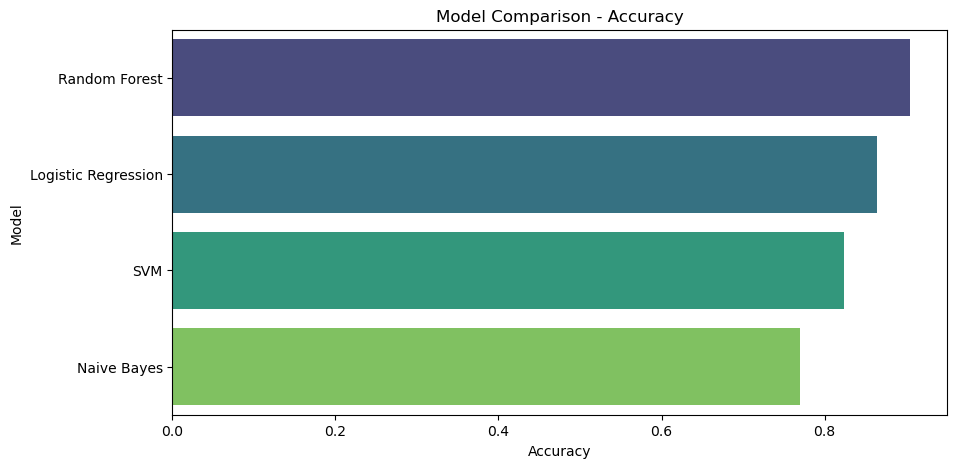

C:\Users\Admin\AppData\Local\Temp\ipykernel_11424\3462711911.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="F1-Score", y="Model", data=results_df, palette="coolwarm")


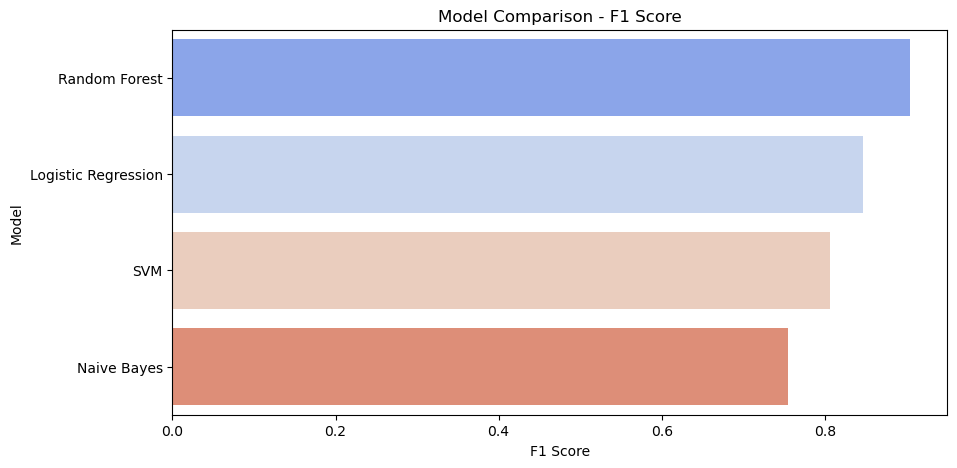

,Model,Accuracy,Precision,Recall,F1-Score
1,Random Forest,0.905405,0.905258,0.905405,0.905068
0,Logistic Regression,0.864865,0.836196,0.864865,0.847225
2,SVM,0.824324,0.793011,0.824324,0.806738
3,Naive Bayes,0.770270,0.766123,0.770270,0.755168


In [9]:
# Convert results to DataFrame
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

# 📊 Accuracy Comparison
plt.figure(figsize=(10,5))
sns.barplot(x="Accuracy", y="Model", data=results_df, palette="viridis")
plt.title("Model Comparison - Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.show()

# 📊 F1-Score Comparison
plt.figure(figsize=(10,5))
sns.barplot(x="F1-Score", y="Model", data=results_df, palette="coolwarm")
plt.title("Model Comparison - F1 Score")
plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.show()

results_df


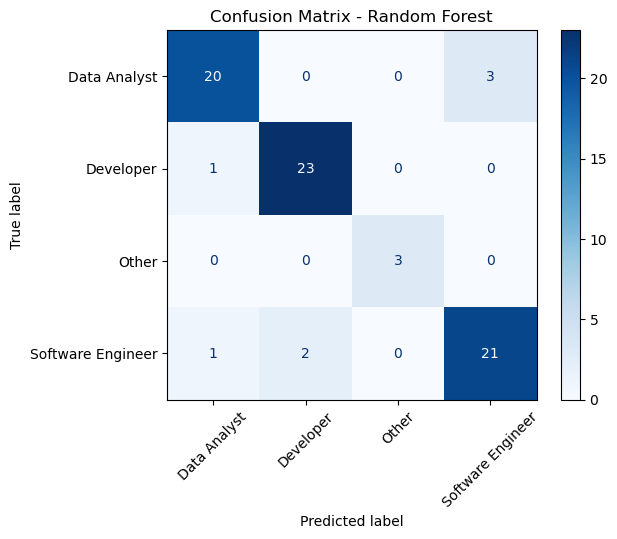

In [10]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, cmap="Blues", xticks_rotation=45)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


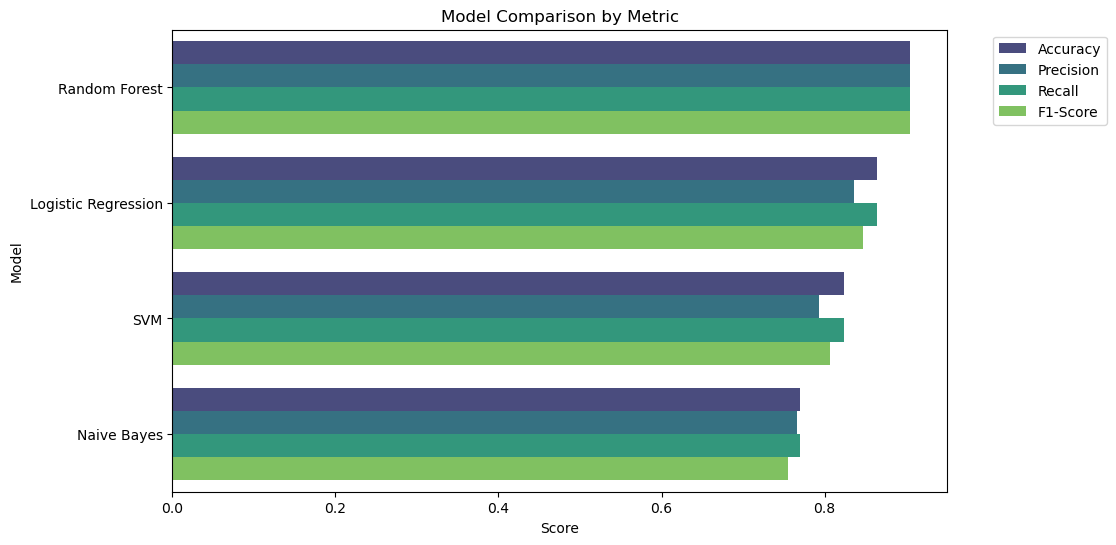

In [11]:
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 6))
sns.barplot(data=results_melted, x="Score", y="Model", hue="Metric", palette="viridis")
plt.title("Model Comparison by Metric")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


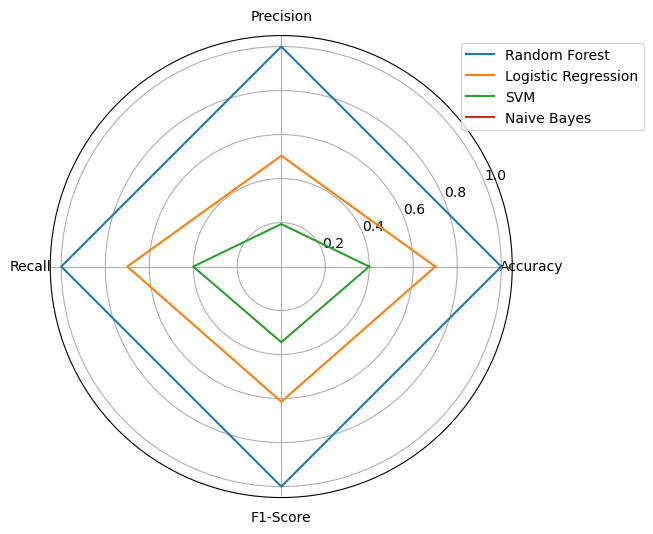

In [13]:
from math import pi

# Normalize scores to 0–1 range
normalized = results_df.copy()
normalized.iloc[:, 1:] = (normalized.iloc[:, 1:] - normalized.iloc[:, 1:].min()) / (normalized.iloc[:, 1:].max() - normalized.iloc[:, 1:].min())

labels = normalized.columns[1:]
num_vars = len(labels)

plt.figure(figsize=(6, 6))
for i, row in normalized.iterrows():
    values = row[1:].tolist()
    values += values[:1]  # close the circle
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]
    plt.polar(angles, values, label=row["Model"])
plt.xticks(angles[:-1], labels)
plt.legend(bbox_to_anchor=(1.3, 1))
plt.show()


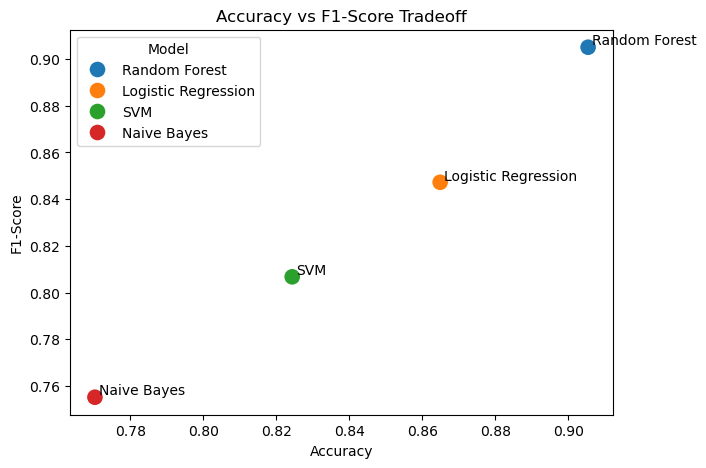

In [14]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=results_df, x="Accuracy", y="F1-Score", hue="Model", s=150, palette="tab10")
for i, row in results_df.iterrows():
    plt.text(row["Accuracy"] + 0.001, row["F1-Score"] + 0.001, row["Model"])
plt.title("Accuracy vs F1-Score Tradeoff")
plt.xlabel("Accuracy")
plt.ylabel("F1-Score")
plt.show()


C:\Users\Admin\AppData\Local\Temp\ipykernel_11424\2417560601.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df_ranked, x="F1-Score", y="Model", palette="crest")


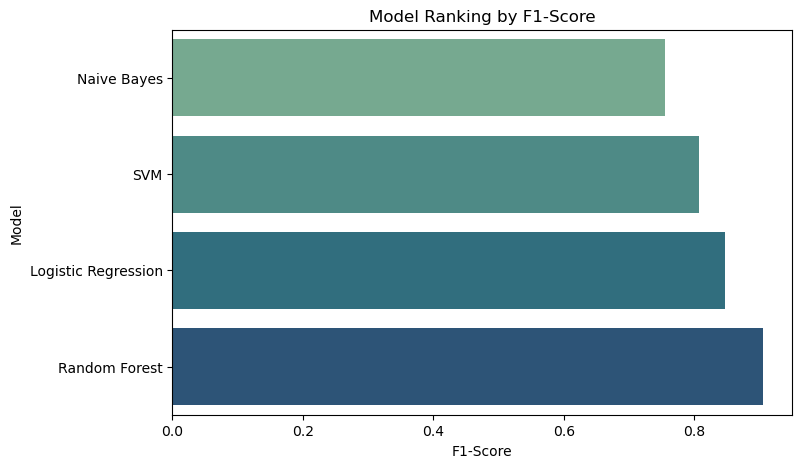

In [15]:
results_df_ranked = results_df.sort_values("F1-Score", ascending=True)
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df_ranked, x="F1-Score", y="Model", palette="crest")
plt.title("Model Ranking by F1-Score")
plt.show()


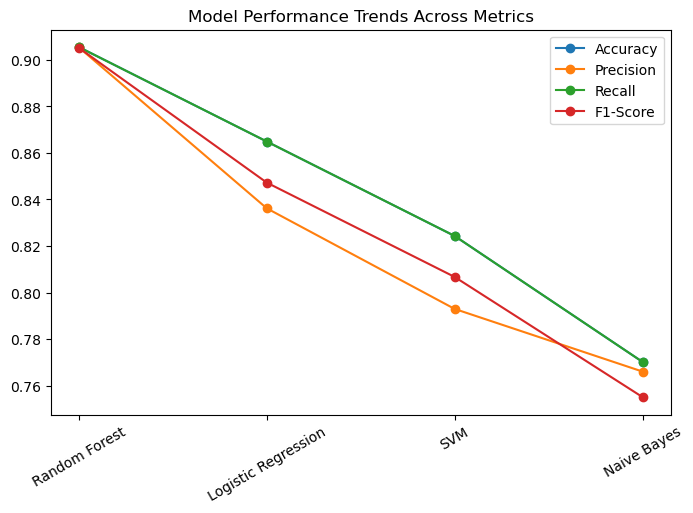

In [16]:
plt.figure(figsize=(8, 5))
for metric in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    plt.plot(results_df["Model"], results_df[metric], marker="o", label=metric)
plt.title("Model Performance Trends Across Metrics")
plt.xticks(rotation=30)
plt.legend()
plt.show()
